# Plant Pathology ResNet-50 — Drive Predictor

This notebook performs prediction only. It does **not** train the model.

It mounts Google Drive and automatically loads:

`MyDrive/plant_project/resnet50_complete/plant_pathology_resnet50_complete.pt`

Run each cell in order, authorize Drive, and upload one or more leaf photographs.

## 1. Setup

In [ ]:
from google.colab import drive, files
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

import torch
import torch.nn as nn
from torchvision import models, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. Load the trained model from Google Drive

Authorize the Google account that contains the `plant_project` folder. The checkpoint is loaded automatically; no model-file upload is required.

In [ ]:
drive.mount("/content/gdrive")

checkpoint_path = Path(
    "/content/gdrive/MyDrive/plant_project/"
    "resnet50_complete/plant_pathology_resnet50_complete.pt"
)

if not checkpoint_path.exists():
    raise FileNotFoundError(
        "The complete checkpoint was not found at:\n"
        f"{checkpoint_path}\n\n"
        "Open the ResNet-50 training notebook and run Section 11 once."
    )

# Only load checkpoints that you created or otherwise trust.
try:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )
except TypeError:
    checkpoint = torch.load(checkpoint_path, map_location=device)

required_keys = {"model_state_dict", "classes", "thresholds"}
missing_keys = required_keys.difference(checkpoint)
if missing_keys:
    raise ValueError(
        "The file is not the complete inference checkpoint. "
        f"Missing: {sorted(missing_keys)}"
    )

architecture = checkpoint.get("architecture", "resnet50")
if architecture != "resnet50":
    raise ValueError(
        f"This notebook expects ResNet-50, but the checkpoint contains: {architecture}"
    )

classes = list(checkpoint["classes"])
thresholds = np.asarray(checkpoint["thresholds"], dtype=np.float32)

model = models.resnet50(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(checkpoint.get("dropout", 0.35)),
    nn.Linear(model.fc.in_features, len(classes)),
)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device).eval()

config = checkpoint.get("preprocessing", {})
predict_transform = transforms.Compose([
    transforms.Resize(config.get("resize", 256)),
    transforms.CenterCrop(
        config.get("center_crop", checkpoint.get("image_size", 224))
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        config.get("mean", [0.485, 0.456, 0.406]),
        config.get("std", [0.229, 0.224, 0.225]),
    ),
])

print("\nModel loaded successfully from Google Drive.")
print("Classes:", classes)
print("No training was performed.")

Mounted at /content/gdrive

Model loaded successfully from Google Drive.
Classes: ['complex', 'frog_eye_leaf_spot', 'healthy', 'powdery_mildew', 'rust', 'scab']
No training was performed.


## 3. Upload leaf photographs and predict

Upload one or more leaf photographs (.jpg, .jpeg, .png, .webp, or .bmp).


Saving images (15).jpg to images (15).jpg

Image: images (15).jpg
Prediction: rust, complex


,class,probability,threshold,predicted
0,rust,96.02%,0.73,True
1,complex,86.10%,0.77,True
2,frog_eye_leaf_spot,7.97%,0.59,False
3,scab,6.64%,0.75,False
4,powdery_mildew,0.35%,0.70,False
5,healthy,0.09%,0.43,False


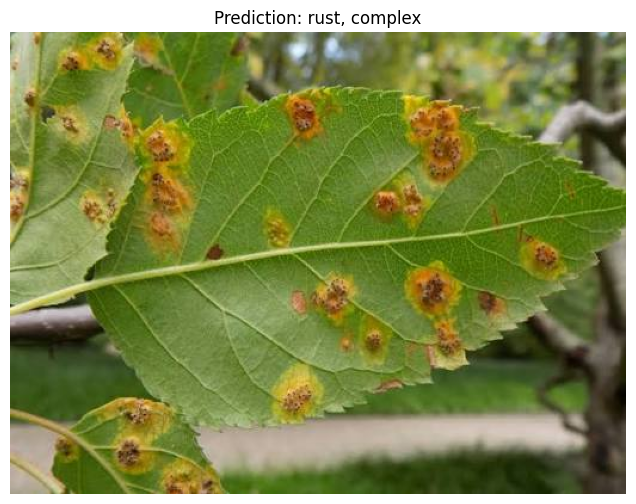

In [ ]:
def predict_leaf(image_path):
    image_path = Path(image_path)

    try:
        with Image.open(image_path) as opened_image:
            image = opened_image.convert("RGB")
    except (UnidentifiedImageError, OSError):
        print(f"Skipped {image_path.name}: not a readable image.")
        return None

    tensor = predict_transform(image).unsqueeze(0).to(device)

    with torch.inference_mode():
        probabilities = (
            torch.sigmoid(model(tensor))
            .squeeze(0)
            .cpu()
            .numpy()
        )

    decisions = probabilities >= thresholds
    results = pd.DataFrame({
        "class": classes,
        "probability": probabilities,
        "threshold": thresholds,
        "predicted": decisions,
    }).sort_values("probability", ascending=False).reset_index(drop=True)

    predicted_labels = results.loc[results["predicted"], "class"].tolist()

    if "healthy" in predicted_labels and len(predicted_labels) > 1:
        prediction = "UNCERTAIN — healthy and disease signals conflict"
    elif predicted_labels:
        prediction = ", ".join(predicted_labels)
    else:
        prediction = "UNCERTAIN — no class exceeded its threshold"

    print(f"\nImage: {image_path.name}")
    print(f"Prediction: {prediction}")
    display(results.style.format({
        "probability": "{:.2%}",
        "threshold": "{:.2f}",
    }))

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {prediction}")
    plt.show()

    return {"prediction": prediction, "probabilities": results}


print("Upload one or more leaf photographs (.jpg, .jpeg, .png, .webp, or .bmp).")
uploaded_images = files.upload()
valid_extensions = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

for filename in uploaded_images:
    if Path(filename).suffix.lower() not in valid_extensions:
        print(f"Skipped {filename}: unsupported image format.")
        continue
    predict_leaf(filename)

## Predict more images

To test additional photographs during the same Colab session, rerun only Section 3. The model remains loaded in memory and Drive does not need to be mounted again.